In [1]:
# Import libraries
import os
import numpy as np                                      
import pandas as pd                                    
import scipy.stats as stats                            
import matplotlib.pyplot as plt                        
import seaborn as sns                                   
import plotly.graph_objects as go                       

from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder   
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV,StratifiedKFold                                     
from sklearn import datasets                                                      
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA      
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA   
from sklearn.neighbors import KNeighborsClassifier                              
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,precision_recall_fscore_support, classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
import statsmodels.api as sm                     # Statistical models
import statsmodels.formula.api as smf            # Statistical models with formula supports 


Import pre-processed data

In [2]:
train = pd.read_csv('data/processed/train_preprocessed_v2.csv', index_col=0)
test = pd.read_csv('data/processed/test_preprocessed_v2.csv', index_col=0)
train_labels = pd.read_csv('data/processed/y_train.csv', index_col=0)

Check each table 

In [3]:
train.head(3)

,Var2,Var3,Var5,Var6,Var7,Var8,Var9,Var10,Var11,Var13,...,Var14992_is_missing,Var14994_is_missing,Var14995_is_missing,Var14996_is_missing,Var14997_is_missing,Var14998_is_missing,Var14999_is_missing,Var15000_is_missing,row_missing_count,row_missing_pct
ID,,,,,,,,,,,,,,,,,,,,,
502504,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,1,1,1,1,458,3.053333
197332,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,1,1,1,1,527,3.513333
277830,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,1,0,1,1,460,3.066667


In [4]:
train_labels.head(3)

,Target_appetency
ID,
502504,0
197332,0
277830,0


In [5]:
test.head(3)

,Var2,Var3,Var5,Var6,Var7,Var8,Var9,Var10,Var11,Var13,...,Var14992_is_missing,Var14994_is_missing,Var14995_is_missing,Var14996_is_missing,Var14997_is_missing,Var14998_is_missing,Var14999_is_missing,Var15000_is_missing,row_missing_count,row_missing_pct
ID,,,,,,,,,,,,,,,,,,,,,
877149,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,1,0,1,1,473,3.153333
109603,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,1,1,1,1,501,3.340000
560424,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,1,1,1,1,504,3.360000


# Logistic regression 

Logistic Regression was selected for its strong ability to address binary classification problems while also providing interpretable results. Although the variables in this dataset are anonymized and offer limited direct business insight, the model remains valuable because if the marketing team has access to the original feature meanings it can help to identify which factors most influence customer behavior.

Since the mayority of the variables have different measure and meanings, is important to scale first. In this case, the scaling process is done before the model because cross validation is done after testing a simple model. 

In [ ]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

: 

## Lasso

Due to the high dimensionality of the dataset, L1-regularized Logistic Regression (Lasso) was applied as an embedded feature selection method. By introducing an L1 penalty, the model automatically shrinks less relevant coefficients to zero, removing variables that are not informative.

In [ ]:
logistic_base = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.01,    
    max_iter=1000)
selector = SelectFromModel(logistic_base)
selector.fit(train_scaled, train_labels.iloc[:, 0])

# 2. Reduce data 
X_train_reduced = selector.transform(train_scaled)
X_test_reduced = selector.transform(test_scaled)

print(train_scaled.shape)
print(X_train_reduced.shape)

Create a function to evaluate the model, getting auc, accuracy, f1 score and confusion matrix 

In [ ]:

def evaluate_model(model, X_train, y_train, name):
    # Predictions
    y_prob_train = model.predict_proba(X_train)[:, 1]
    y_pred_train = model.predict(X_train)

    # metrics 
    
    precision, recall, f1, support = precision_recall_fscore_support(
        y_train,
        y_pred_train,
        labels=[0, 1],
        zero_division=0
    )

    # Results
    results = {
        'Model': name,

        # Global
        'AUC_train': roc_auc_score(y_train, y_prob_train),
        'Accuracy_train': accuracy_score(y_train, y_pred_train),
        'F1_train': f1_score(y_train, y_pred_train),
        'Confusion_matrix_train': confusion_matrix(y_train, y_pred_train),

        # Class 0
        'Precision_class_0': precision[0],
        'Recall_class_0': recall[0],
        'F1_class_0': f1[0],
        'Support_class_0': support[0],

        # Class 1
        'Precision_class_1': precision[1],
        'Recall_class_1': recall[1],
        'F1_class_1': f1[1],
        'Support_class_1': support[1],

        # Complete classification report 
        'Classification_report': classification_report(
            y_train,
            y_pred_train,
            digits=4,
            zero_division=0
        )
    }

    return results

In [ ]:
logistic_base.fit(train, train_labels.iloc[:, 0])

# Predictions
y_pred_train = logistic_base.predict_proba(train)[:, 1]

auc_train = roc_auc_score(train_labels, y_pred_train)

print(f'Train AUC: {auc_train:.4f}')

In [ ]:
results = []
results.append(evaluate_model(logistic_base, train, train_labels.iloc[:, 0], "LR base lasso"))
resultslr0 = pd.DataFrame(results)

c:\Users\Source\.conda\envs\py\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


ValueError: X has 9279 features, but LogisticRegression is expecting 44 features as input.

In [ ]:
resultslr0

In [ ]:
disp_dt = ConfusionMatrixDisplay(
    confusion_matrix=resultslr0['Confusion_matrix_train'][0])

disp_dt.plot(cmap='Greens', colorbar=False)
plt.title('Confusion Matrix - LR base lasso')
plt.show()

A Logistic Regression pipeline was created to tune the regularization strength while keeping Lasso regularization for feature selection. Standardization was included inside the pipeline to avoid data leakage, and Stratified Cross-Validation was used to preserve the class distribution across folds. Since the dataset is imbalanced

In [100]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,precision_recall_fscore_support, classification_report

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ("logit", LogisticRegression(max_iter=1000))
])


parameters = {"logit__C": [0.001, 0.01, 0.1, 1, 10],
              "logit__penalty": ['l1'],
              "logit__solver": ['liblinear'],
              "logit__class_weight": ["balanced"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#grid search 

grid = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1,
    verbose=2,
    refit=True)



grid.fit(train,  train_labels.iloc[:, 0])

print(grid.best_params_)
print(grid.best_score_)

best_model0 = grid.best_estimator_

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END logit__C=0.001, logit__class_weight=balanced, logit__penalty=l1, logit__solver=liblinear; total time=  42.8s
[CV] END logit__C=0.001, logit__class_weight=balanced, logit__penalty=l1, logit__solver=liblinear; total time=  42.6s
[CV] END logit__C=0.001, logit__class_weight=balanced, logit__penalty=l1, logit__solver=liblinear; total time=  41.5s
[CV] END logit__C=0.001, logit__class_weight=balanced, logit__penalty=l1, logit__solver=liblinear; total time=  23.4s
[CV] END logit__C=0.001, logit__class_weight=balanced, logit__penalty=l1, logit__solver=liblinear; total time=  15.8s
[CV] END logit__C=0.01, logit__class_weight=balanced, logit__penalty=l1, logit__solver=liblinear; total time= 1.5min
[CV] END logit__C=0.01, logit__class_weight=balanced, logit__penalty=l1, logit__solver=liblinear; total time= 2.4min
[CV] END logit__C=0.01, logit__class_weight=balanced, logit__penalty=l1, logit__solver=liblinear; total time=  57.0s

In this case, the optimal model was achieved with a very low C value (0.001), indicating that stronger regularization was necessary to improve generalization performance. This suggests that given the dataset’s high dimensionality a more aggressive penalty helped eliminate a larger number of less informative variables, reducing noise and overfitting.

In [101]:
# Predictions
y_train_lrlasso = best_model0.predict_proba(train)[:, 1]
y_test_lrlasso = best_model0.predict_proba(test)[:, 1]

auc_lrlasso = roc_auc_score(train_labels.iloc[:, 0], y_train_lrlasso)

print(f'Train AUC: {auc_lrlasso:.4f}')


Train AUC: 0.8605


In [108]:
results = []
results.append(evaluate_model(best_model0, train, train_labels.iloc[:, 0], "LR with Lasso"))
resultslr1 = pd.DataFrame(results)


The results show that the Lasso Logistic Regression model is capable of identifying a large proportion of customers with a high likelihood of purchasing, correctly classifying 450 positive cases while missing only 84 actual buyers. This strong recall is particularly valuable given the highly imbalanced nature of the dataset, where failing to detect potential high-value customers represents the most critical error.

However, this improved sensitivity comes at the cost of a substantial number of false positives, with 9,431 customers incorrectly classified as likely buyers when their true label was 0. Also, its F1-score remains low at approximately 0.095 due to poor precision

In [109]:
resultslr1.iloc[:,:4]

,Model,AUC_train,Accuracy_train,F1_train
0,LR with Lasso,0.860509,0.724867,0.094758


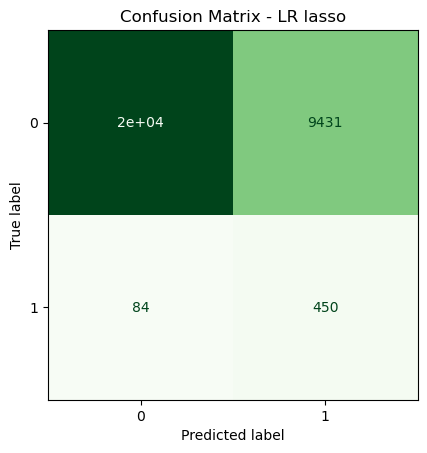

In [ ]:
disp_dt = ConfusionMatrixDisplay(
    confusion_matrix=resultslr1['Confusion_matrix_train'][0])

disp_dt.plot(cmap='Greens', colorbar=False)
plt.title('Confusion Matrix - LR lasso')
plt.show()

## 

 **Logistic + k-best** 

A different approach was implemented by introducing Ridge (L2) regularization into GridSearch, which shrinks coefficients instead of eliminating them like Lasso. Additional feature reduction was applied using SelectKBest to retain the most relevant variables. Both preprocessing steps were integrated within the pipeline to prevent data leakage, ensuring feature selection occurred independently within each fold. With all these adjustments  fits were tried by the grid

In [110]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ("kbest", SelectKBest(score_func=f_classif)),
    ("logit", LogisticRegression(max_iter=1000))])

parameters = {
    "kbest__k": [20,30,50],
    "logit__C": [0.001, 0.01, 0.1, 1, 10],
    "logit__penalty": ["l1", "l2"],
    "logit__solver": ["liblinear","saga"]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1,
    verbose=2,
    refit=True)

grid.fit(train, train_labels.iloc[:, 0])

print("Best params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

best_model = grid.best_estimator_

Fitting 5 folds for each of 60 candidates, totalling 300 fits


c:\Users\Source\.conda\envs\py\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [8582 8664 8665 8670 8685 8690 8715 8729 8744 8757 8773 8780 8792 8801
 8805 8825 8844 8848 8852 8856 8866 8897 8918 8938 8944 8954 8955 8957
 8962 8963 8971 8987 8996 8999 9000 9011 9018 9023 9025 9038 9050 9056
 9067 9070 9074 9077 9079 9082 9083 9084 9091 9095 9100 9102 9110 9112
 9113 9114 9116 9117 9126 9129 9134 9135 9139 9141 9143 9144 9147 9150
 9156 9166 9171 9182 9185 9190 9192 9200 9202 9203 9204 9208 9209 9212
 9213 9214 9219 9227 9228 9229 9235 9238 9239 9240 9244 9246 9250 9254
 9255 9256 9257 9260 9263 9264 9265 9266 9268 9269 9270 9276] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Source\.conda\envs\py\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


[CV] END kbest__k=20, logit__C=0.001, logit__penalty=l1, logit__solver=liblinear; total time=   8.3s


c:\Users\Source\.conda\envs\py\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [8664 8665 8670 8685 8690 8715 8729 8744 8757 8773 8780 8792 8801 8805
 8825 8844 8848 8852 8856 8866 8897 8918 8938 8944 8954 8955 8957 8962
 8963 8971 8987 8996 8999 9000 9011 9018 9023 9025 9038 9050 9056 9067
 9070 9074 9077 9079 9082 9083 9084 9091 9095 9100 9102 9110 9112 9113
 9114 9116 9117 9126 9129 9134 9135 9139 9141 9143 9144 9147 9150 9156
 9166 9171 9182 9185 9190 9192 9200 9202 9203 9204 9208 9209 9212 9213
 9214 9219 9227 9228 9229 9235 9238 9239 9240 9244 9246 9250 9254 9255
 9256 9257 9260 9263 9264 9265 9266 9268 9269 9270 9276] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Source\.conda\envs\py\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


[CV] END kbest__k=20, logit__C=0.001, logit__penalty=l1, logit__solver=liblinear; total time=   8.3s


...

[CV] END kbest__k=50, logit__C=10, logit__penalty=l2, logit__solver=saga; total time=  20.4s


c:\Users\Source\.conda\envs\py\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [8566 8664 8665 8670 8685 8690 8715 8729 8744 8757 8773 8780 8792 8801
 8805 8825 8844 8848 8852 8856 8866 8897 8918 8938 8944 8954 8955 8957
 8962 8963 8971 8987 8996 8999 9000 9011 9018 9023 9025 9038 9050 9056
 9067 9070 9074 9077 9079 9082 9083 9084 9091 9095 9100 9102 9110 9112
 9113 9114 9116 9117 9126 9129 9134 9135 9139 9141 9143 9144 9147 9150
 9156 9166 9171 9182 9185 9190 9192 9200 9202 9203 9204 9208 9209 9212
 9213 9214 9219 9227 9228 9229 9235 9238 9239 9240 9244 9246 9250 9254
 9255 9256 9257 9260 9263 9264 9265 9266 9268 9269 9270 9276] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Source\.conda\envs\py\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


[CV] END kbest__k=50, logit__C=10, logit__penalty=l2, logit__solver=saga; total time=  19.5s


c:\Users\Source\.conda\envs\py\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [8664 8665 8670 8685 8690 8715 8729 8744 8757 8773 8780 8792 8801 8805
 8825 8844 8848 8852 8856 8866 8897 8918 8938 8944 8954 8955 8957 8962
 8963 8971 8987 8996 8999 9000 9011 9018 9023 9025 9038 9050 9056 9067
 9070 9074 9077 9079 9082 9083 9084 9091 9095 9100 9102 9110 9112 9113
 9114 9116 9117 9126 9129 9134 9135 9139 9141 9143 9144 9147 9150 9156
 9166 9171 9182 9185 9190 9192 9200 9202 9203 9204 9208 9209 9212 9213
 9214 9219 9227 9228 9229 9235 9238 9239 9240 9244 9246 9250 9254 9255
 9256 9257 9260 9263 9264 9265 9266 9268 9269 9270 9276] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Source\.conda\envs\py\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Best params: {'kbest__k': 50, 'logit__C': 10, 'logit__penalty': 'l2', 'logit__solver': 'liblinear'}
Best CV AUC: 0.8411639961919152


Best performance was achieved with 50 variables, a regularization of 0.1, with l1 model a libliear model. 

In [111]:
#Select best model and fit 

# Predictions
y_train_lrkbest1 = best_model.predict_proba(train)[:, 1]
y_test_lrkbest1 = best_model.predict_proba(test)[:, 1]

auc_lrkbest1 = roc_auc_score(train_labels.iloc[:, 0], y_train_lrkbest1)

print(f'Train AUC: {auc_lrkbest1:.4f}')

Train AUC: 0.8466


In [112]:
results = []
results.append(evaluate_model(best_model, train, train_labels.iloc[:, 0], "LR k-best"))
resultslr3 = pd.DataFrame(results)

Although the model achieves a similar AUC score, the F1-score and confusion matrix reveal extremely poor classification performance when focusing on the confusion matrix and f1 score. Specifically, the model predicts the majority class (customers who do not purchase), failing to effectively identify future buyers. Due to the severe class imbalance, this behavior still produces an apparently high accuracy of 98%, but this metric is misleading. The model performs poorly for the actual business objective, which is to detect customers with purchasing potential.

In [113]:
resultslr3.iloc[:,:4]

,Model,AUC_train,Accuracy_train,F1_train
0,LR k-best,0.846625,0.982167,0.0


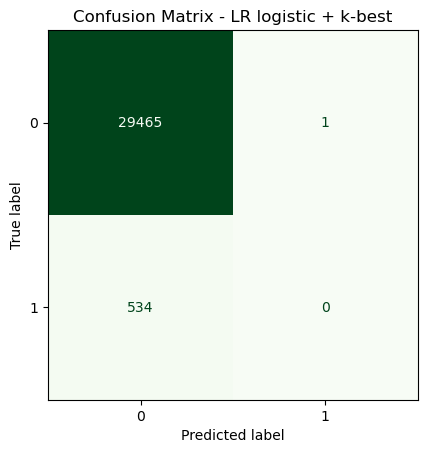

In [114]:
disp_dt = ConfusionMatrixDisplay(
    confusion_matrix=resultslr3['Confusion_matrix_train'][0])

disp_dt.plot(cmap='Greens', colorbar=False)
plt.title('Confusion Matrix - LR logistic + k-best')
plt.show()